# Fraud EDA

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

In [2]:
# basic setup
DATA_PATH = "fraud_data_encoded_v2.csv"
LABEL_COL = "fraud"
POSITIVE_LABEL = "fraud"

FLAG_MAPPINGS = {
    "ocr_tampering_flag": {"yes": 1, "no": 0},
    "front_liveness_fakeprint": {"true": 1, "false": 0},
    "back_liveness_fakeprint": {"true": 1, "false": 0},
    "front_object_liveness": {"success": 1, "failure": 0},
    "back_object_liveness": {"success": 1, "failure": 0},
    "liveness3d_object_liveness": {"success": 1, "failure": 0},
}

NUMERIC_COLS = ["tampering_flag", "year", "month", "day"]

DUPLICATE_KEY_COLS = [
    "tokenid",
    "ocr_cccd",
    "finger_print",
    "ipaddress",
    "client_session",
]

FEATURE_COLS_TO_CHECK = [
    "req_path",
    "ocr_tampering_flag",
    "front_liveness_fakeprint",
    "front_object_liveness",
    "back_liveness_fakeprint",
    "back_object_liveness",
    "liveness3d_object_liveness",
    "tampering_flag",
]

In [3]:
def normalize_text(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().str.lower()


def safe_map(series: pd.Series, mapping: dict) -> pd.Series:
    return normalize_text(series).map(mapping)


def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    # turn common flag columns into numeric values
    for col, mapping in FLAG_MAPPINGS.items():
        if col in data.columns:
            data[col] = safe_map(data[col], mapping)

    # coerce a few time / flag columns to numeric
    for col in NUMERIC_COLS:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    # binary target for later modeling
    if LABEL_COL in data.columns:
        data["target"] = normalize_text(data[LABEL_COL]).map({"fraud": 1, "unknown": 0})

    return data


def build_column_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "nunique": df.nunique(dropna=False),
        "sample_value": [
            df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else np.nan
            for col in df.columns
        ],
    })
    return summary.sort_values(["missing_pct", "nunique"], ascending=[False, False])


def label_distribution(df: pd.DataFrame, label_col: str = LABEL_COL) -> pd.DataFrame:
    counts = df[label_col].value_counts(dropna=False)
    ratios = (df[label_col].value_counts(normalize=True, dropna=False) * 100).round(4)
    return pd.DataFrame({"count": counts, "ratio_pct": ratios})


def plot_bar(series: pd.Series, title: str, ylabel: str, rotation: int = 60, figsize=(10, 5)):
    plt.figure(figsize=figsize)
    plt.bar(series.index.astype(str), series.values)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()


def get_low_cardinality_columns(df: pd.DataFrame, max_unique: int = 10) -> list:
    return [col for col in df.columns if df[col].nunique(dropna=False) <= max_unique]


def build_duplicate_summary(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    rows = []

    for col in cols:
        if col not in df.columns:
            continue

        value_counts = df[col].value_counts(dropna=False)
        rows.append({
            "column": col,
            "nunique": int(df[col].nunique(dropna=False)),
            "repeated_keys_gt1": int((value_counts > 1).sum()),
            "rows_in_repeated_keys": int(value_counts[value_counts > 1].sum()),
            "repeat_row_ratio_pct": round(value_counts[value_counts > 1].sum() / len(df) * 100, 2),
            "top_5_counts": value_counts.head(5).to_dict(),
        })

    return pd.DataFrame(rows).sort_values("repeat_row_ratio_pct", ascending=False)


def crosstab_count_and_rate(df: pd.DataFrame, feature_col: str, label_col: str = LABEL_COL):
    count_table = pd.crosstab(df[feature_col], df[label_col], dropna=False)
    rate_table = pd.crosstab(df[feature_col], df[label_col], normalize="index", dropna=False)
    return count_table, rate_table


def plot_positive_rate(df: pd.DataFrame, feature_col: str, label_col: str = LABEL_COL):
    _, rate_table = crosstab_count_and_rate(df, feature_col, label_col)

    if POSITIVE_LABEL not in rate_table.columns:
        print(f"'{POSITIVE_LABEL}' is not present in the rate table for {feature_col}.")
        return

    rate_series = rate_table[POSITIVE_LABEL].sort_values(ascending=False)
    plot_bar(
        rate_series,
        title=f"Fraud rate by {feature_col}",
        ylabel="Fraud rate",
        rotation=30,
        figsize=(7, 4),
    )

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df = preprocess_data(df_raw)

print("Raw shape:")
print(df_raw.shape)

print("\nShape after preprocessing:")
print(df.shape)

print("\nPreview:")
display(df.head())

Raw shape:
(31332, 45)

Shape after preprocessing:
(31332, 46)

Preview:


,req_uuid,req_path,client_session,finger_print,os_version,ma_may,tokenid,req_timestamplog,res_timestamplog,ocr_tampering_flag,hash_front,hash_back,year,month,day,liveness_hash_front,liveness_front_uuid,front_liveness_fakeprint,front_object_liveness,liveness_timestamplog_front,liveness_timestamplog_back,liveness_hash_back,liveness_back_uuid,back_liveness_fakeprint,back_object_liveness,facecompare_uuid,compare_img_face,facecompare_timestamplog,liveness3d_uuid,ln3d_near_img,ln3d_far_image,liveness3d_object_liveness,liveness3d_timestamplog,geolite_ipaddress,country,city,latitude,longitude,flag_123456,tampering_flag,asn,embedding,fraud,ocr_cccd,ipaddress,target
0,386a8cfc-bafb-11f0-a8ec-051123dc3638-d7e3abbf-...,/ai/v1/ocr/id,IOS_iPhone12Pro_ios26.0.1_Device_3.6.4_B3D7F69...,IOS_iPhone12Pro_ios26.0.1_Device_3.6.4_B3D7F69...,ios26.0.1,iPhone12Pro,cd084afa-ffdd-5019-e053-63199f0a95fb,1762424859455,1762424859455,1,idg20251106-cf2f7e4b-758f-5c05-e053-63199f0a56...,idg20251106-cf2f7e4b-758f-5c05-e053-63199f0a56...,2025.0,11.0,6.0,idg20251106-cf2f7e4b-758f-5c05-e053-63199f0a56...,2faab6a5-bafb-11f0-92d5-65eca1dd8cef-831ac399-...,0.0,1.0,1.762425e+12,1.762425e+12,idg20251106-cf2f7e4b-758f-5c05-e053-63199f0a56...,387eb180-bafb-11f0-b650-6f3309284245-2a2955ef-...,0,1,3d560311-bafb-11f0-90ab-edc10265a318-4a16a614-...,idg20251106-cf2f7e4b-758f-5c05-e053-63199f0a56...,1762424867708,3d7ec0a3-bafb-11f0-a8ec-c11b6992a963-f8ac3774-...,idg20251106-cf2f7e4b-758f-5c05-e053-63199f0a56...,idg20251106-cf2f7e4b-758f-5c05-e053-63199f0a56...,1.0,1762424867975,NaN,NaN,NaN,NaN,NaN,yes/false/success/false/success/success,0,NaN,PawJ0bz2gBi83fy+PIy0SLzQ71U910e6PMNBND1+xCW+xh...,unknown,f6870267b1396cb6,119.79.56.240,0
1,8e7fdd25-bafa-11f0-96f7-6b7bacd30488-66258f5e-...,/ai/v2/ocr/id,IOS_iPhone11Pro_ios18.6.2_Device_3.6.4_9646931...,IOS_iPhone11Pro_ios18.6.2_Device_3.6.4_9646931...,ios18.6.2,iPhone11Pro,b0e4c220-5037-6d93-e053-604fc10ac0c8,1762424574381,1762424574381,1,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,2025.0,11.0,6.0,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,8a292d7f-bafa-11f0-a8ec-a72eafb7d647-40c5600d-...,1.0,0.0,1.762425e+12,1.762425e+12,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,8e7444b7-bafa-11f0-afe5-c703ad553382-dfb7dea8-...,1,0,96e02eaf-bafa-11f0-9bac-e3bc026a38eb-d11bfe9a-...,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,1762424588435,96fbf3c6-bafa-11f0-9149-4581ba53900b-cdb20ab6-...,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,1.0,1762424588617,NaN,NaN,NaN,NaN,NaN,yes/true/failure/true/failure/success,1,NaN,PQ/mp7wJfNc6eM+KPceRuju1YRU8jcqYPONxf70e4rO8XQ...,unknown,c2bb2ea8fb2b6ff1,117.188.44.46,0
2,15778ff7-bafb-11f0-982f-756f357867b7-409b0677-...,/ai/v2/ocr/id,IOS_iPhone14_ios18.6.2_Device_3.6.4_DC8E5561-F...,IOS_iPhone14_ios18.6.2_Device_3.6.4_DC8E5561-F...,ios18.6.2,iPhone14,b0e4c220-5037-6d93-e053-604fc10ac0c8,1762424800820,1762424800820,1,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,2025.0,11.0,6.0,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,0f2d9b86-bafb-11f0-92d5-b1e3a2af7224-a85af6c4-...,0.0,1.0,1.762425e+12,1.762425e+12,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,1569fb4b-bafb-11f0-a8ec-479185e43c1a-4d3ff457-...,0,1,19c0d23c-bafb-11f0-afe5-95a2a4388703-0d50f32c-...,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,1762424808011,19c8c1b3-bafb-11f0-982f-7d9c0ac0a801-59516721-...,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,idg20251106-cf30976d-4f2d-437b-e053-63199f0a7f...,1.0,1762424808063,NaN,NaN,NaN,NaN,NaN,yes/false/success/false/success/success,0,NaN,PY4J2LxqH4A80CAEPuCyPb0+DsY8H4ASvaIsST3PbD89ZS...,unknown,fbabc8a6cba08e93,117.176.186.64,0
3,93222c8b-bb0b-11f0-a8ec-01c8a5391763-d14fc014-...,/ai/v1/ocr/id,IOS_iPhone11_ios18.1.1_Device_3.6.4_1C7C7F2B-B...,IOS_iPhone11_ios18.1.1_Device_3.6.4_1C7C7F2B-B...,ios18.1.1,iPhone11,cd084afa-f

## 1. Quick look

This check before going deeper:
- how many rows and columns we have
- data types
- label distribution
- whether the `target` column was created correctly


In [5]:
print("Dtype summary:")
dtype_summary = df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")
display(dtype_summary)

print("\nLabel distribution:")
display(label_distribution(df, LABEL_COL))

if "target" in df.columns:
    print("\nTarget distribution:")
    display(df["target"].value_counts(dropna=False).rename_axis("target").reset_index(name="count"))

Dtype summary:


,dtype,count
0,object,27
1,float64,10
2,int64,9



Label distribution:


,count,ratio_pct
fraud,,
unknown,31293,99.8755
fraud,39,0.1245



Target distribution:


,target,count
0,0,31293
1,1,39


## 2. Missing values and cardinality

This table is usually the most useful one early on. It gives a quick view of:
- columns with a lot of missing data
- columns with extremely high cardinality
- low-cardinality columns that may behave like flags or statuses


In [6]:
column_summary = build_column_summary(df)

print("Column summary:")
display(column_summary)

Column summary:


,dtype,missing_count,missing_pct,nunique,sample_value
asn,object,31149,99.42,5,AS45899
geolite_ipaddress,object,23224,74.12,4105,27.68.138.133
city,object,23224,74.12,59,Hanoi
latitude,float64,23224,74.12,59,21.0184
longitude,float64,23224,74.12,59,105.8461
country,object,23224,74.12,4,Vietnam
flag_123456,object,136,0.43,55,yes/false/success/false/success/success
liveness3d_object_liveness,float64,97,0.31,3,1.0
embedding,object,70,0.22,31263,PawJ0bz2gBi83fy+PIy0SLzQ71U910e6PMNBND1+xCW+xh...
liveness_timestamplog_front,float64,39,0.12,30485,1762424844776.0


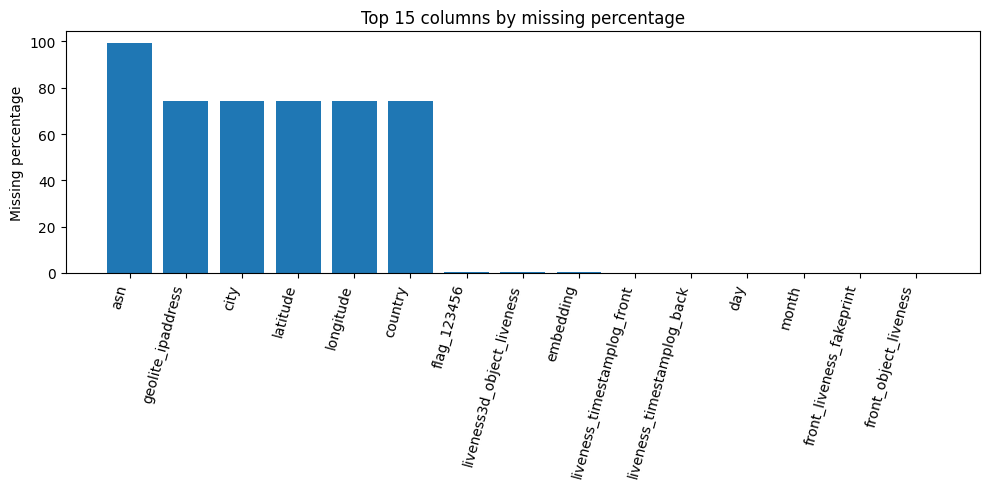

In [7]:
missing_nonzero = column_summary.loc[column_summary["missing_count"] > 0, "missing_pct"].head(15)

if len(missing_nonzero) > 0:
    plot_bar(
        missing_nonzero,
        title="Top 15 columns by missing percentage",
        ylabel="Missing percentage",
        rotation=75,
        figsize=(10, 5),
    )
else:
    print("No missing values found.")

Low-cardinality columns (<= 10 unique values):


day                           10
asn                            5
country                        4
liveness3d_object_liveness     3
front_object_liveness          3
front_liveness_fakeprint       3
month                          3
year                           2
ocr_tampering_flag             2
req_path                       2
back_object_liveness           2
back_liveness_fakeprint        2
tampering_flag                 2
fraud                          2
target                         2
dtype: int64


Very high-cardinality columns (>= 1000 unique values):


embedding                      31263
facecompare_uuid               31227
facecompare_timestamplog       31226
liveness3d_uuid                31209
liveness3d_timestamplog        31207
ln3d_far_image                 31186
compare_img_face               31186
ln3d_near_img                  31183
req_uuid                       30545
req_timestamplog               30542
res_timestamplog               30542
liveness_front_uuid            30527
liveness_back_uuid             30520
hash_back                      30514
liveness_hash_back             30514
hash_front                     30514
liveness_hash_front            30514
liveness_timestamplog_front    30485
liveness_timestamplog_back     30482
client_session                 29594
ocr_cccd                       21535
ipaddress                      17893
finger_print                   17174
geolite_ipaddress               4105
dtype: int64

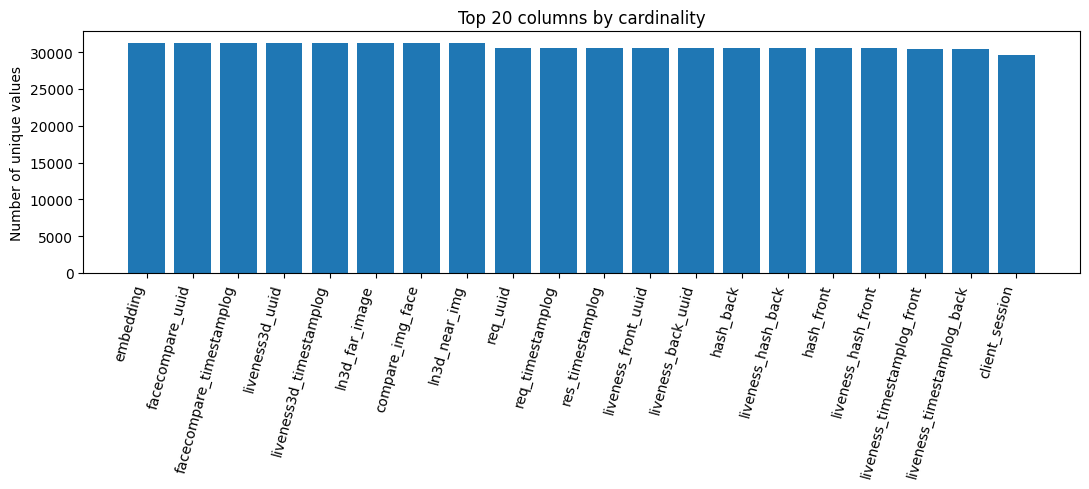

In [8]:
cardinality = df.nunique(dropna=False).sort_values(ascending=False)

print("Low-cardinality columns (<= 10 unique values):")
display(cardinality[cardinality <= 10])

print("\nVery high-cardinality columns (>= 1000 unique values):")
display(cardinality[cardinality >= 1000])

plot_bar(
    cardinality.head(20),
    title="Top 20 columns by cardinality",
    ylabel="Number of unique values",
    rotation=75,
    figsize=(11, 5),
)

## 3. Small-category columns

I usually inspect low-cardinality columns one by one because they are easy to read and often expose:
- status fields
- hidden binary flags
- odd values or bad formatting


In [9]:
low_card_cols = get_low_cardinality_columns(df, max_unique=10)

print("Low-cardinality columns:")
print(low_card_cols)

Low-cardinality columns:
['req_path', 'ocr_tampering_flag', 'year', 'month', 'day', 'front_liveness_fakeprint', 'front_object_liveness', 'back_liveness_fakeprint', 'back_object_liveness', 'liveness3d_object_liveness', 'country', 'tampering_flag', 'asn', 'fraud', 'target']



===== req_path | 2 unique values =====


,req_path,count
0,/ai/v1/ocr/id,18327
1,/ai/v2/ocr/id,13005


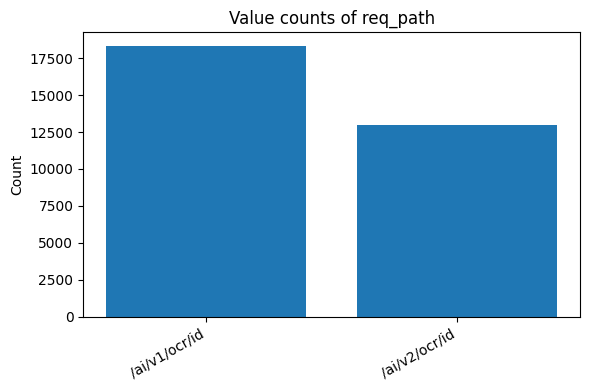


===== ocr_tampering_flag | 2 unique values =====


,ocr_tampering_flag,count
0,1,30079
1,0,1253


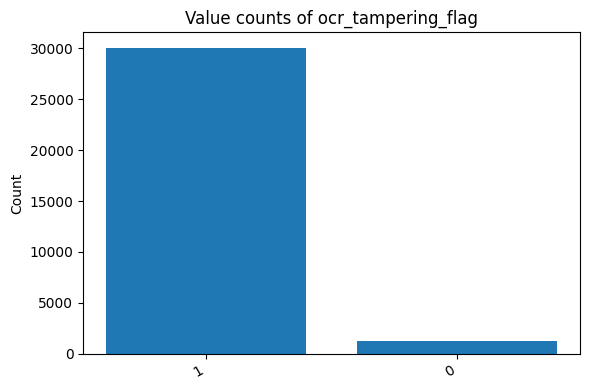


===== year | 2 unique values =====


,year,count
0,2025.0,31293
1,NaN,39


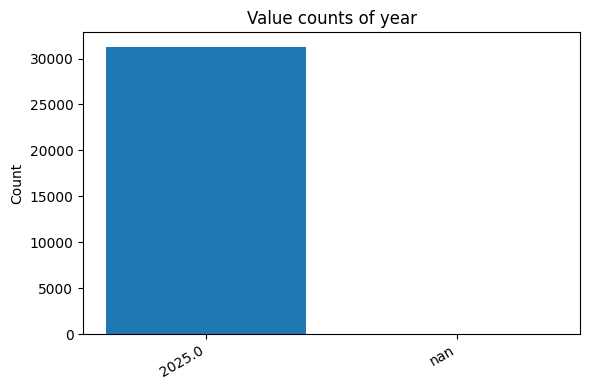


===== month | 3 unique values =====


,month,count
0,11.0,29453
1,10.0,1840
2,NaN,39


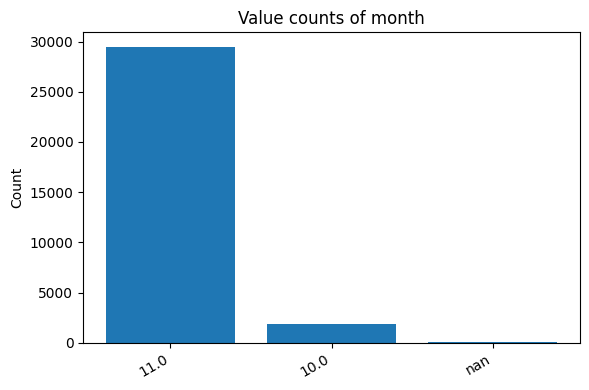


===== day | 10 unique values =====


,day,count
0,12.0,6386
1,5.0,4587
2,4.0,4391
3,3.0,4182
4,6.0,3489
5,7.0,3424
6,2.0,2520
7,29.0,1840
8,13.0,474
9,NaN,39



===== front_liveness_fakeprint | 3 unique values =====


,front_liveness_fakeprint,count
0,0.0,28485
1,1.0,2808
2,NaN,39


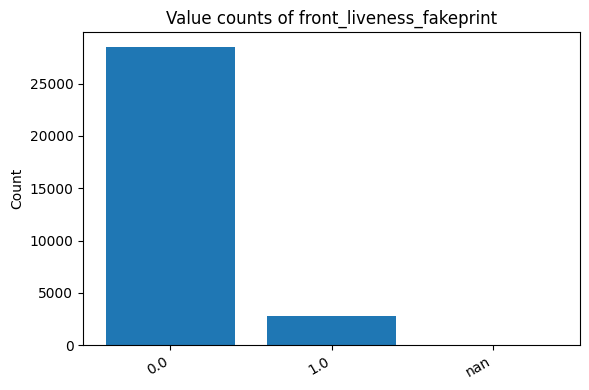


===== front_object_liveness | 3 unique values =====


,front_object_liveness,count
0,1.0,28341
1,0.0,2952
2,NaN,39


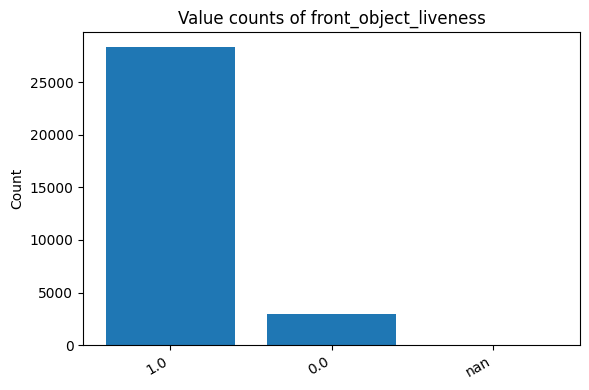


===== back_liveness_fakeprint | 2 unique values =====


,back_liveness_fakeprint,count
0,0,28335
1,1,2997


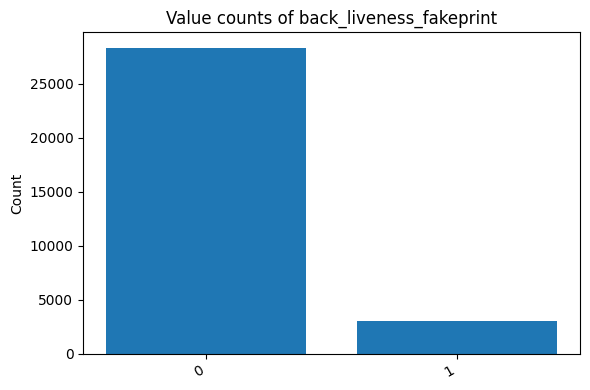


===== back_object_liveness | 2 unique values =====


,back_object_liveness,count
0,1,28498
1,0,2834


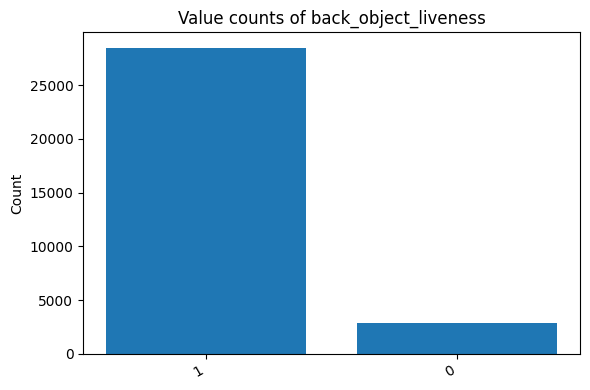


===== liveness3d_object_liveness | 3 unique values =====


,liveness3d_object_liveness,count
0,1.0,28610
1,0.0,2625
2,NaN,97


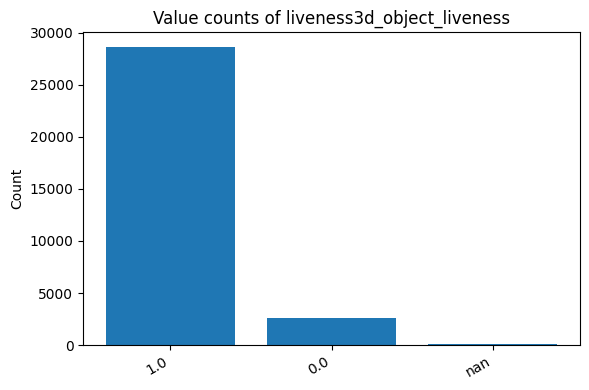


===== country | 4 unique values =====


,country,count
0,NaN,23224
1,Vietnam,8104
2,France,2
3,Cambodia,2


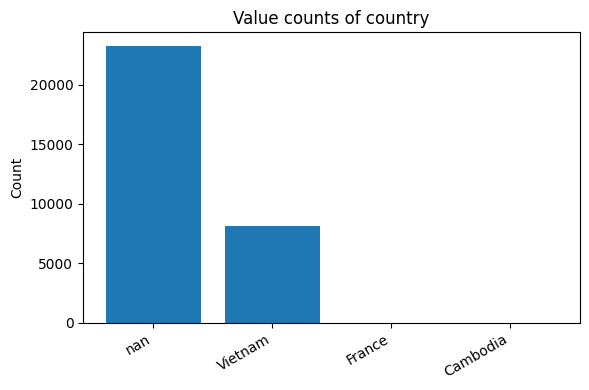


===== tampering_flag | 2 unique values =====


,tampering_flag,count
0,0,24908
1,1,6424


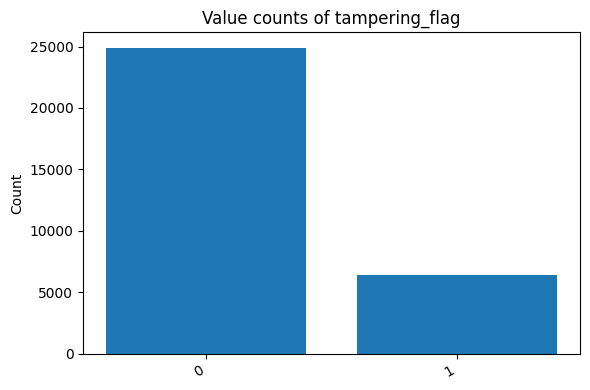


===== asn | 5 unique values =====


,asn,count
0,NaN,31149
1,AS45899,103
2,AS7552,73
3,AS13335,6
4,AS18403,1


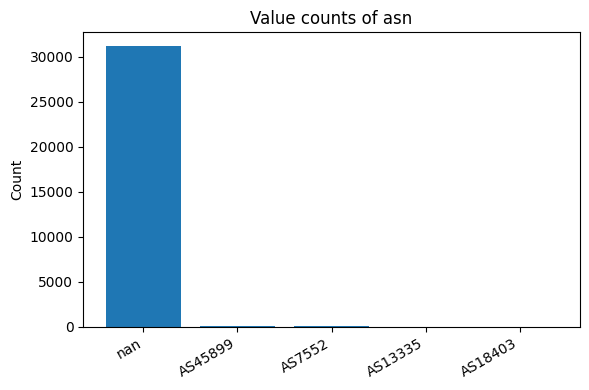


===== fraud | 2 unique values =====


,fraud,count
0,unknown,31293
1,fraud,39


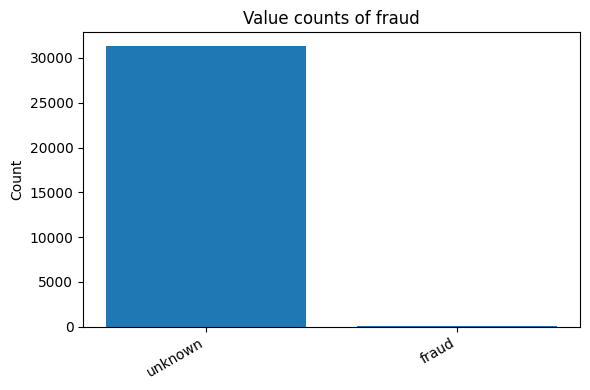


===== target | 2 unique values =====


,target,count
0,0,31293
1,1,39


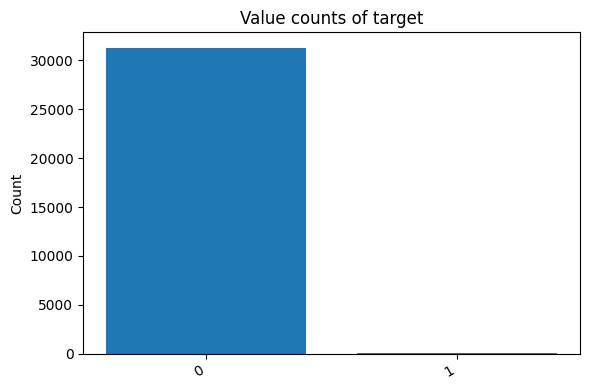

In [10]:
for col in low_card_cols:
    print(f"\n===== {col} | {df[col].nunique(dropna=False)} unique values =====")
    value_counts = df[col].value_counts(dropna=False)
    display(value_counts.rename_axis(col).reset_index(name="count"))

    if len(value_counts) <= 8:
        plot_bar(
            value_counts,
            title=f"Value counts of {col}",
            ylabel="Count",
            rotation=30,
            figsize=(6, 4),
        )

## 4. Repeated keys

The old notebook already hinted that a few columns repeat a lot. I kept that part, but turned it into one summary table so it is easier to compare key-like columns side by side.


In [11]:
duplicate_summary = build_duplicate_summary(df, DUPLICATE_KEY_COLS)

print("Duplicate summary:")
display(duplicate_summary)

Duplicate summary:


,column,nunique,repeated_keys_gt1,rows_in_repeated_keys,repeat_row_ratio_pct,top_5_counts
0,tokenid,56,50,31326,99.98,"{'b0e4c220-5037-6d93-e053-604fc10ac0c8': 9139,..."
2,finger_print,17174,6272,20430,65.20,{'ANDROID_ZTE2050RU_31_Device_3.6.6_ef65eedc72...
3,ipaddress,17893,5940,19379,61.85,"{'49.43.55.18': 91, '18.229.44.90': 83, '117.1..."
1,ocr_cccd,21535,5394,15191,48.48,"{'b486a411dc04c06c': 64, '6207a796b002feae': 5..."
4,client_session,29594,1088,2826,9.02,{'ANDROID_ZTE2050RU_31_Device_3.6.6_ef65eedc72...


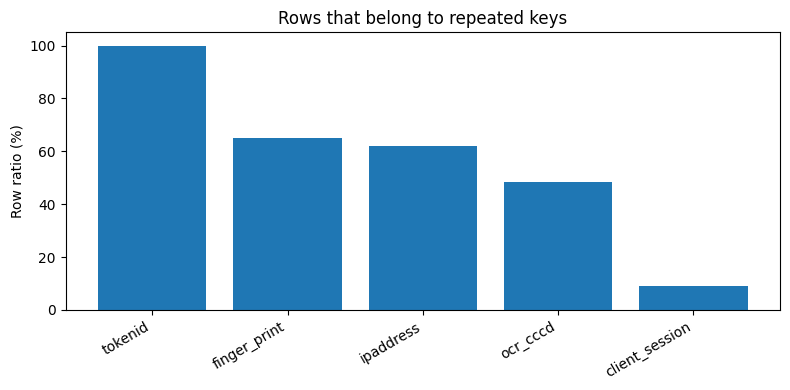


=== tokenid | most repeated values ===


,tokenid,count
0,b0e4c220-5037-6d93-e053-604fc10ac0c8,9139
1,1aaad7b6-b1d9-6592-e063-63199f0ad151,4794
2,cd084afa-ffdd-5019-e053-63199f0a95fb,4427
3,1eaaf52c-9f12-6de0-e063-62199f0a5a7a,3794
4,bf8211fe-8387-d09f-e053-604fc10aaaa2,3642



=== finger_print | most repeated values ===


,finger_print,count
0,ANDROID_ZTE2050RU_31_Device_3.6.6_ef65eedc72b3...,91
1,IOS_iPhone12ProMax_ios18.5_Device_3.6.4_13CD09...,68
2,IOS_iPhone7Plus_ios15.8.5_Device_3.6.4_461FF5E...,58
3,IOS_iPhone16ProMax_ios18.6.2_Device_3.6.4_F596...,46
4,IOS_iPhone12_ios18.6.2_Device_3.6.4_574FDEB2-E...,44



=== ipaddress | most repeated values ===


,ipaddress,count
0,49.43.55.18,91
1,18.229.44.90,83
2,117.168.79.158,76
3,117.188.48.185,73
4,226.257.78.22,67



=== ocr_cccd | most repeated values ===


,ocr_cccd,count
0,b486a411dc04c06c,64
1,6207a796b002feae,57
2,b6ac221463885362,44
3,c3d5594c3f920a25,27
4,4afa29054cf7c893,25



=== client_session | most repeated values ===


,client_session,count
0,ANDROID_ZTE2050RU_31_Device_3.6.6_ef65eedc72b3...,48
1,ANDROID_ZTE2050RU_31_Device_3.6.6_ef65eedc72b3...,20
2,ANDROID_Star5_29_Device_3.5.6__1760245078595_,11
3,ANDROID_CPH1819_29_Device_3.6.6_22ac0e6de1f496...,11
4,ANDROID_SM-A042F_31_Device_3.6.6_ccee1cbac4166...,10


In [12]:
if not duplicate_summary.empty:
    plot_bar(
        duplicate_summary.set_index("column")["repeat_row_ratio_pct"],
        title="Rows that belong to repeated keys",
        ylabel="Row ratio (%)",
        rotation=30,
        figsize=(8, 4),
    )

    for _, row in duplicate_summary.iterrows():
        print(f"\n=== {row['column']} | most repeated values ===")
        display(pd.DataFrame(list(row["top_5_counts"].items()), columns=[row["column"], "count"]))

Top IPs by fraud rate:


,ip_clean,total_count,fraud_count,fraud_rate
0,107.126.144.98,35,35,1.0
1,111.158.40.190,3,3,1.0
2,5.58.46.220,1,1,1.0
3,49.43.55.18,91,0,0.0
4,18.229.44.90,83,0,0.0
5,117.168.79.158,76,0,0.0
6,117.188.48.185,73,0,0.0
7,226.257.78.22,67,0,0.0
8,18.235.51.236,57,0,0.0
9,117.164.30.29,56,0,0.0


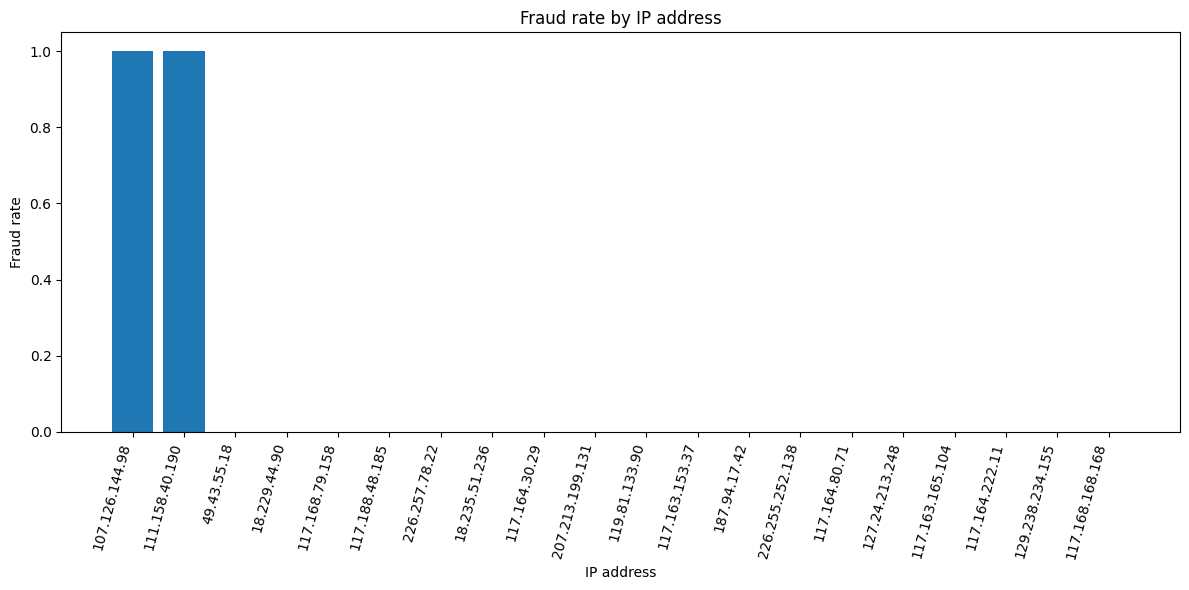

In [17]:
# Fraud rate by ipaddress
tmp = df.copy()
tmp["fraud_clean"] = tmp["fraud"].astype(str).str.strip().str.lower()
tmp["ip_clean"] = tmp["ipaddress"].astype(str).str.strip()

# drop empty / nan-like IP values
tmp = tmp[
    tmp["ip_clean"].notna()
    & (tmp["ip_clean"] != "")
    & (tmp["ip_clean"].str.lower() != "nan")
].copy()

tmp["is_fraud"] = (tmp["fraud_clean"] == "fraud").astype(int)

ip_stats = (
    tmp.groupby("ip_clean")
    .agg(
        total_count=("ip_clean", "size"),
        fraud_count=("is_fraud", "sum"),
    )
    .reset_index()
)

ip_stats["fraud_rate"] = ip_stats["fraud_count"] / ip_stats["total_count"]

# sort for inspection
ip_stats = ip_stats.sort_values(
    ["fraud_rate", "total_count"],
    ascending=[False, False]
).reset_index(drop=True)

print("Top IPs by fraud rate:")
display(ip_stats.head(20))

# plot only IPs with at least 2 records to avoid noisy one-off IPs
plot_df = (
    ip_stats[ip_stats["total_count"] >= 2]
    .head(20)
    .copy()
)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["ip_clean"], plot_df["fraud_rate"])
plt.xticks(rotation=75, ha="right")
plt.xlabel("IP address")
plt.ylabel("Fraud rate")
plt.title("Fraud rate by IP address")
plt.tight_layout()
plt.show()

## 5. Feature vs label

Here I only check a small set of business-facing fields that looked relevant in the first pass.

For each column:
- a count table
- a row-wise rate table
- a fraud-rate chart when the number of groups is still small enough to read



===== req_path vs fraud =====
Count table:


fraud,fraud,unknown
req_path,,
/ai/v1/ocr/id,39,18288
/ai/v2/ocr/id,0,13005


Rate table:


fraud,fraud,unknown
req_path,,
/ai/v1/ocr/id,0.002128,0.997872
/ai/v2/ocr/id,0.000000,1.000000


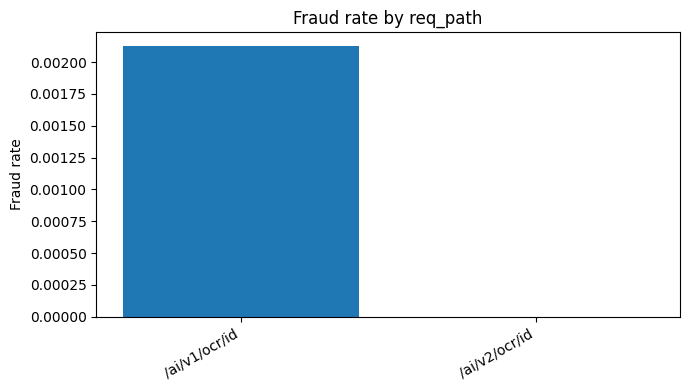


===== ocr_tampering_flag vs fraud =====
Count table:


fraud,fraud,unknown
ocr_tampering_flag,,
0,3,1250
1,36,30043


Rate table:


fraud,fraud,unknown
ocr_tampering_flag,,
0,0.002394,0.997606
1,0.001197,0.998803


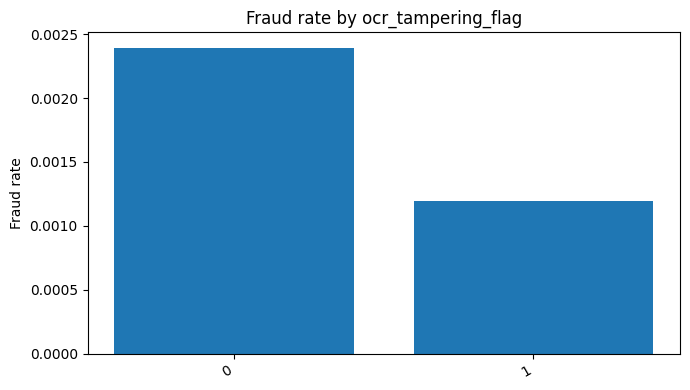


===== front_liveness_fakeprint vs fraud =====
Count table:


fraud,fraud,unknown
front_liveness_fakeprint,,
0.0,39,28446
1.0,0,2808
NaN,0,39


Rate table:


fraud,fraud,unknown
front_liveness_fakeprint,,
0.0,0.001369,0.998631
1.0,0.000000,1.000000
NaN,0.000000,1.000000


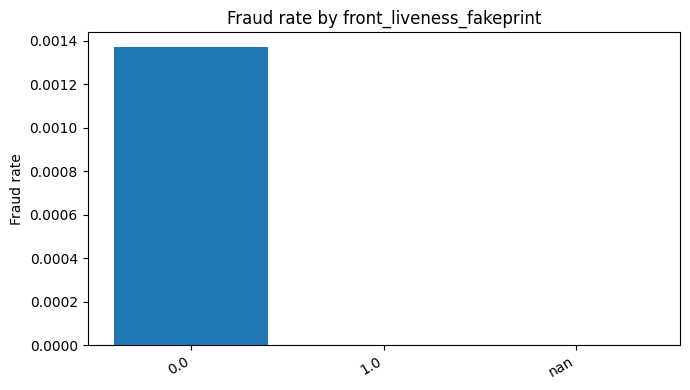


===== front_object_liveness vs fraud =====
Count table:


fraud,fraud,unknown
front_object_liveness,,
0.0,0,2952
1.0,39,28302
NaN,0,39


Rate table:


fraud,fraud,unknown
front_object_liveness,,
0.0,0.000000,1.000000
1.0,0.001376,0.998624
NaN,0.000000,1.000000


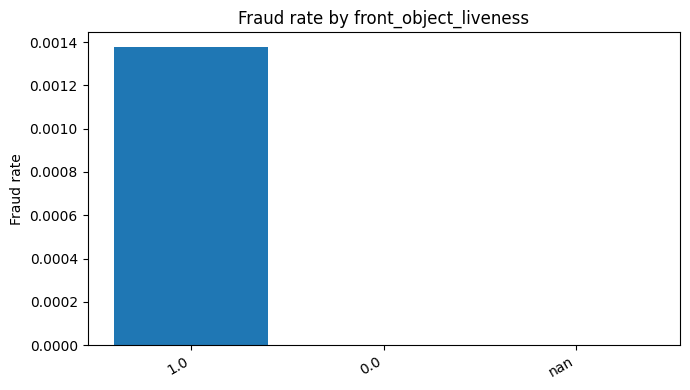


===== back_liveness_fakeprint vs fraud =====
Count table:


fraud,fraud,unknown
back_liveness_fakeprint,,
0,39,28296
1,0,2997


Rate table:


fraud,fraud,unknown
back_liveness_fakeprint,,
0,0.001376,0.998624
1,0.000000,1.000000


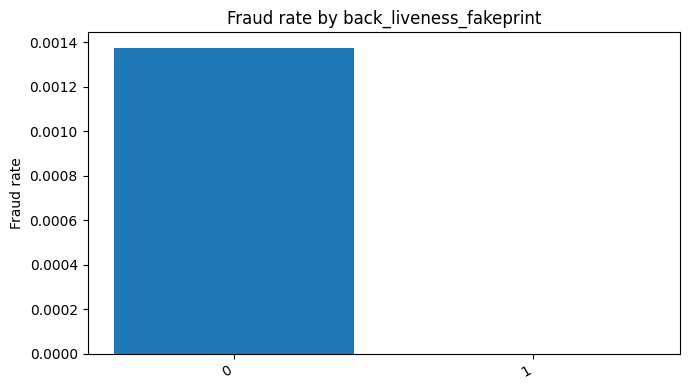


===== back_object_liveness vs fraud =====
Count table:


fraud,fraud,unknown
back_object_liveness,,
0,0,2834
1,39,28459


Rate table:


fraud,fraud,unknown
back_object_liveness,,
0,0.000000,1.000000
1,0.001369,0.998631


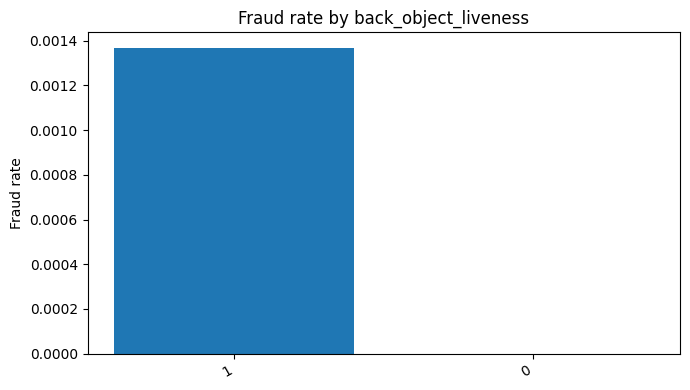


===== liveness3d_object_liveness vs fraud =====
Count table:


fraud,fraud,unknown
liveness3d_object_liveness,,
0.0,18,2607
1.0,21,28589
NaN,0,97


Rate table:


fraud,fraud,unknown
liveness3d_object_liveness,,
0.0,0.006857,0.993143
1.0,0.000734,0.999266
NaN,0.000000,1.000000


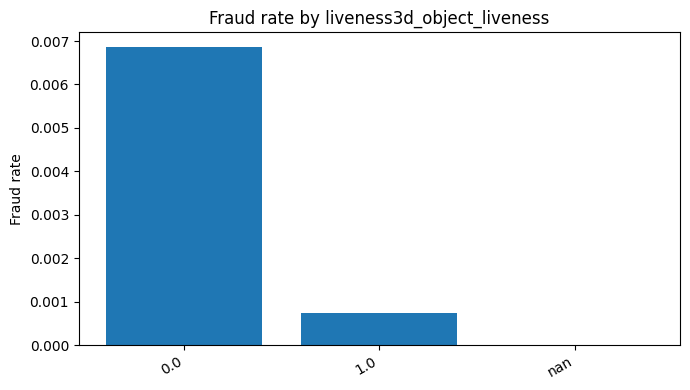


===== tampering_flag vs fraud =====
Count table:


fraud,fraud,unknown
tampering_flag,,
0,20,24888
1,19,6405


Rate table:


fraud,fraud,unknown
tampering_flag,,
0,0.000803,0.999197
1,0.002958,0.997042


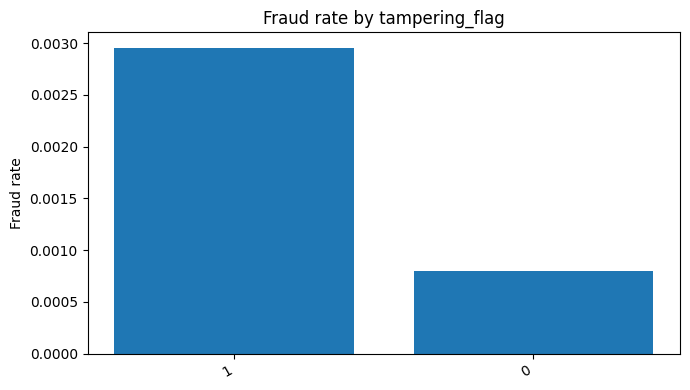

In [13]:
for col in FEATURE_COLS_TO_CHECK:
    if col not in df.columns:
        continue

    print(f"\n===== {col} vs {LABEL_COL} =====")
    count_table, rate_table = crosstab_count_and_rate(df, col, LABEL_COL)

    print("Count table:")
    display(count_table)

    print("Rate table:")
    display(rate_table)

    if df[col].nunique(dropna=False) <= 8:
        plot_positive_rate(df, col, LABEL_COL)

## 6. A few notes before modeling

After this EDA pass, the next thing I would watch out for is leakage.

A few practical points:
1. drop or review ID-like columns such as UUIDs, hashes, timestamps, image paths, embeddings
2. consider group-based splits using columns like `ocr_cccd`, `finger_print`, or `tokenid`
3. use fraud-focused metrics instead of raw accuracy
4. keep the feature list fairly small at first, then add complexity only if needed


In [14]:
suspected_id_like_cols = [
    col
    for col in df.columns
    if any(keyword in col.lower() for keyword in ["uuid", "hash", "timestamp", "image", "img", "embedding"])
]

print("Columns that may behave like IDs or leakage-heavy fields:")
print(suspected_id_like_cols)

Columns that may behave like IDs or leakage-heavy fields:
['req_uuid', 'req_timestamplog', 'res_timestamplog', 'hash_front', 'hash_back', 'liveness_hash_front', 'liveness_front_uuid', 'liveness_timestamplog_front', 'liveness_timestamplog_back', 'liveness_hash_back', 'liveness_back_uuid', 'facecompare_uuid', 'compare_img_face', 'facecompare_timestamplog', 'liveness3d_uuid', 'ln3d_near_img', 'ln3d_far_image', 'liveness3d_timestamplog', 'embedding']


In [15]:
fraud_rows = (
    df[df["fraud"].astype(str).str.strip().str.lower() == "fraud"]
    .copy()
    .reset_index(drop=True)
)

print("Number of fraud rows:", len(fraud_rows))
display(fraud_rows)

Number of fraud rows: 39


,req_uuid,req_path,client_session,finger_print,os_version,ma_may,tokenid,req_timestamplog,res_timestamplog,ocr_tampering_flag,hash_front,hash_back,year,month,day,liveness_hash_front,liveness_front_uuid,front_liveness_fakeprint,front_object_liveness,liveness_timestamplog_front,liveness_timestamplog_back,liveness_hash_back,liveness_back_uuid,back_liveness_fakeprint,back_object_liveness,facecompare_uuid,compare_img_face,facecompare_timestamplog,liveness3d_uuid,ln3d_near_img,ln3d_far_image,liveness3d_object_liveness,liveness3d_timestamplog,geolite_ipaddress,country,city,latitude,longitude,flag_123456,tampering_flag,asn,embedding,fraud,ocr_cccd,ipaddress,target
0,08cdf68e-a73b-11f0-982f-4341ff944c5d-6d5b8022-...,/ai/v1/ocr/id,ANDROID_Star5_29_Device_3.5.6__1760245078595_,ANDROID_Star5_29_Device_3.5.6_,29,Star5,bbaf43a8-50b0-f012-e053-604fc10a2a88,1760253244111,1760253244111,1,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,NaN,NaN,NaN,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,ff3a0797-a73a-11f0-a8ec-d1831dcbd5db-717f8487-...,0.0,1.0,NaN,NaN,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,08a8bb04-a73b-11f0-b581-c36055c26705-b12a42e6-...,0,1,1b21bc6a-a73b-11f0-982f-0d9fc471ea3a-119180d3-...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,1760253274859,1b3d8183-a73b-11f0-96f7-bb6b7190717d-43fd5dda-...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,0.0,1760253275041,NaN,NaN,NaN,NaN,NaN,yes/false/success/false/success/failure,1,NaN,NaN,fraud,aac17bb1ce99ff41,107.126.144.98,1
1,60f0d86a-a759-11f0-b650-a9b485f6fb6c-39f6ddde-...,/ai/v1/ocr/id,ANDROID_ZTE2050RU_31_Device_3.5.6__1760266127469_,ANDROID_ZTE2050RU_31_Device_3.5.6_,31,ZTE2050RU,bbaf43a8-50b0-f012-e053-604fc10a2a88,1760266276881,1760266276881,1,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,NaN,NaN,NaN,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,5c36849f-a759-11f0-982f-1f5a34956c4c-de0f01d7-...,0.0,1.0,NaN,NaN,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,60f0d8b3-a759-11f0-90ab-8799aa646edb-4c8c1c67-...,0,1,7c4d16f9-a759-11f0-96f7-0f50a71cb04c-7fa4aa14-...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,1760266322784,7c2cbd4a-a759-11f0-9149-75957b6faf33-df5cc7be-...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,0.0,1760266322572,NaN,NaN,NaN,NaN,NaN,yes/false/success/false/success/failure,1,NaN,NaN,fraud,2cdefccf87412b35,111.158.40.190,1
2,10c7529d-a747-11f0-982f-7f7aeb7ab756-f1bba183-...,/ai/v1/ocr/id,ANDROID_Star5_29_Device_3.5.6__1760254497661_,ANDROID_Star5_29_Device_3.5.6_,29,Star5,bbaf43a8-50b0-f012-e053-604fc10a2a88,1760258411450,1760258411450,1,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,NaN,NaN,NaN,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,0d134ab7-a747-11f0-afe5-99f373a5ef15-7f32bb80-...,0.0,1.0,NaN,NaN,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,10e9a6f1-a747-11f0-96f7-79e6328b716c-b17ea880-...,0,1,24b3441f-a747-11f0-afe5-bdc4c4acc659-e39d8148-...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,1760258444873,2494235e-a747-11f0-afe5-1f0bf15579f8-4413c39a-...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,0.0,1760258444669,NaN,NaN,NaN,NaN,NaN,yes/false/success/false/success/failure,1,NaN,NaN,fraud,0b5343c12a048d4e,107.126.144.98,1
3,4f9ecbf7-a729-11f0-89da-efc17e225162-899482f3-...,/ai/v1/ocr/id,ANDROID_Star5_29_Device_3.5.6__1760245078595_,ANDROID_Star5_29_Device_3.5.6_,29,Star5,bbaf43a8-50b0-f012-e053-604fc10a2a88,1760245631979,1760245631979,1,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,NaN,NaN,NaN,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb...,4c032ec2-a729-11f0-982f-4924639c3a86-d1384021-...,0.0,1.0,NaN,NaN,idg20251012-cf42e8d2-49ef-5b79-e053-63199f0afb.